# Fraud Detection ML Pipeline

This notebook builds a practical fraud-detection pipeline from the available transaction data.

The goal is **not** to build a perfect banking fraud engine. Instead, it demonstrates the main ideas that matter when moving from a classroom model towards a production ML system:

- avoid train/test leakage
- use chronological validation for transaction data
- turn timestamps into useful features
- treat card numbers as identifiers rather than continuous numeric measurements
- derive behavioural features from transaction history
- handle class imbalance without contaminating the evaluation set
- evaluate with fraud-appropriate metrics
- choose a decision threshold using validation data
- persist the model together with the information required for inference

> **Important:** the available dataset is relatively small and does not contain many signals used by real fraud systems, such as device fingerprints, IP reputation, location, account age, authentication events, or rich customer history. The resulting model is therefore a training/demo system, not a production banking fraud detector.

## 1. Imports and configuration

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = Path("bank_transactions.csv")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)


## 2. Load and inspect the transaction data

In [2]:
df = pd.read_csv(DATA_PATH)

required_columns = {
    "sender_card_number",
    "receiver_cc_number",
    "transaction_amount",
    "transaction_date",
    "is_fraud",
}

missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Missing values: {int(df.isna().sum().sum()):,}")

df.head()


Rows: 10,305
Columns: 8
Duplicate rows: 0
Missing values: 0


,first_name,last_name,date_of_birth,sender_card_number,receiver_cc_number,transaction_amount,transaction_date,is_fraud
0,Jacob Salinas,Krista Nolan,2007-05-12,2475480622143887,2529677371753651,74556.99,2022-10-30 04:06:10,0
1,Lisa Castillo,Ronald Bryan,1959-10-12,2715910999405782,5242998865060315,12784.00,2022-05-20 23:46:49,0
2,Melanie Gomez,Elizabeth Brown,1914-07-11,5328978080501084,2536338331446248,36781.67,2022-05-23 05:34:45,0
3,Bradley Evans,Christopher Fisher,2007-10-13,2718649482370361,2276430890454293,86997.56,2022-07-17 19:29:10,0
4,Trevor Gonzalez,Michael Duncan,1913-04-22,2720731806955949,2513298401142431,64527.42,2022-01-08 09:23:23,0


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
first_name,10305,9675,Michael Smith,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_name,10305,9684,Jennifer Smith,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_of_birth,10305,9151,1938-08-26,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sender_card_number,10305.0,NaN,NaN,NaN,3140261770939556.5,1277802846672346.0,2221003242298316.0,2269150975765558.0,2505223656664764.0,2720954912282111.0,5599608670805015.0
receiver_cc_number,10305.0,NaN,NaN,NaN,3150054601283091.5,1281568310751320.25,2221026820717605.0,2270615185420688.0,2512923290956630.0,2720990539980463.0,5599767091865493.0
transaction_amount,10305.0,NaN,NaN,NaN,50127.223444,28808.642168,1.02,25275.29,50164.52,75119.68,99980.42
transaction_date,10305,10303,2022-01-16 05:34:18,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_fraud,10305.0,NaN,NaN,NaN,0.009025,0.094574,0.0,0.0,0.0,0.0,1.0


## 3. Basic fraud-rate analysis

Legitimate transactions: 10,212
Fraudulent transactions: 93
Fraud rate: 0.90%


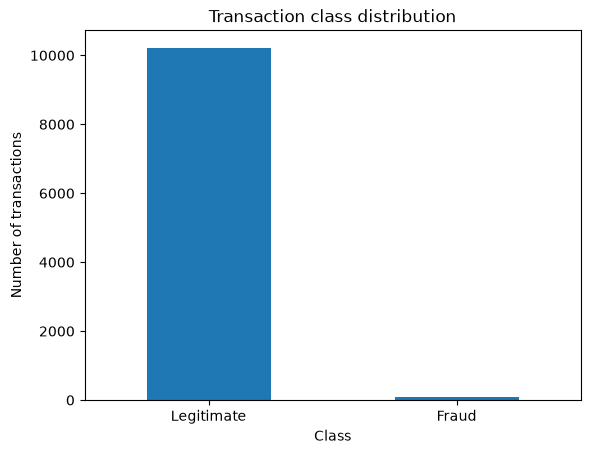

In [4]:
fraud_counts = df["is_fraud"].value_counts().sort_index()
fraud_rate = df["is_fraud"].mean()

print(f"Legitimate transactions: {(df['is_fraud'] == 0).sum():,}")
print(f"Fraudulent transactions: {(df['is_fraud'] == 1).sum():,}")
print(f"Fraud rate: {fraud_rate:.2%}")

ax = fraud_counts.rename(index={0: "Legitimate", 1: "Fraud"}).plot(kind="bar")
ax.set_title("Transaction class distribution")
ax.set_ylabel("Number of transactions")
ax.set_xlabel("Class")
plt.xticks(rotation=0)
plt.show()


### Transaction amounts

In [5]:
amount_summary = df.groupby("is_fraud")["transaction_amount"].describe()
amount_summary.index = ["Legitimate", "Fraud"]
amount_summary


,count,mean,std,min,25%,50%,75%,max
Legitimate,10212.0,50182.885081,28812.508185,1.02,25307.405,50233.66,75169.2825,99980.42
Fraud,93.0,44015.216559,27859.072532,1043.88,19058.350,42390.74,63479.7300,99844.41


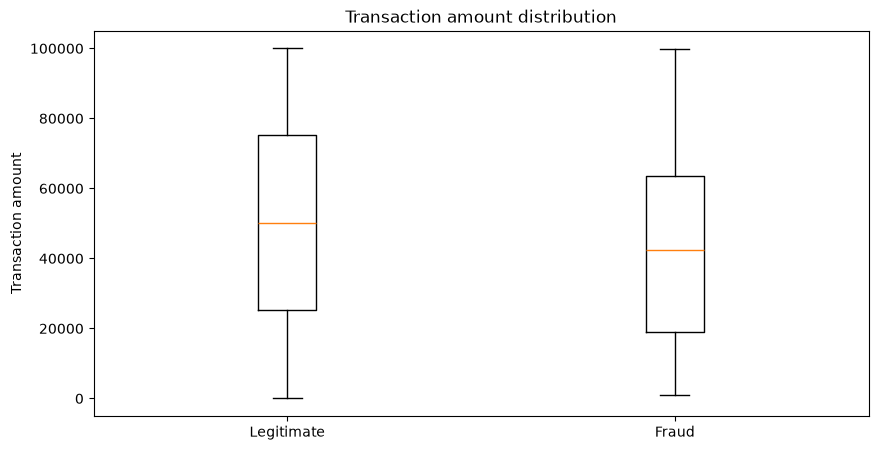

In [7]:
plot_data = [
    df.loc[df["is_fraud"] == 0, "transaction_amount"],
    df.loc[df["is_fraud"] == 1, "transaction_amount"],
]

plt.figure(figsize=(10, 5))
plt.boxplot(
    plot_data,
    tick_labels=["Legitimate", "Fraud"],
    showfliers=False,
)
plt.title("Transaction amount distribution")
plt.ylabel("Transaction amount")
plt.show()

## 4. Time features

A transaction timestamp is useful, but feeding the raw timestamp into a tree model is usually less useful than extracting interpretable components. We derive the hour, day of week, and weekend indicator.

In [8]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

if df["transaction_date"].isna().any():
    raise ValueError("Some transaction_date values could not be parsed.")

df = df.sort_values("transaction_date").reset_index(drop=True)

df["transaction_hour"] = df["transaction_date"].dt.hour
df["transaction_day_of_week"] = df["transaction_date"].dt.dayofweek
df["is_weekend"] = (df["transaction_day_of_week"] >= 5).astype(int)

print(f"Date range: {df['transaction_date'].min()} → {df['transaction_date'].max()}")


Date range: 2022-01-01 00:35:32 → 2022-11-21 19:49:23


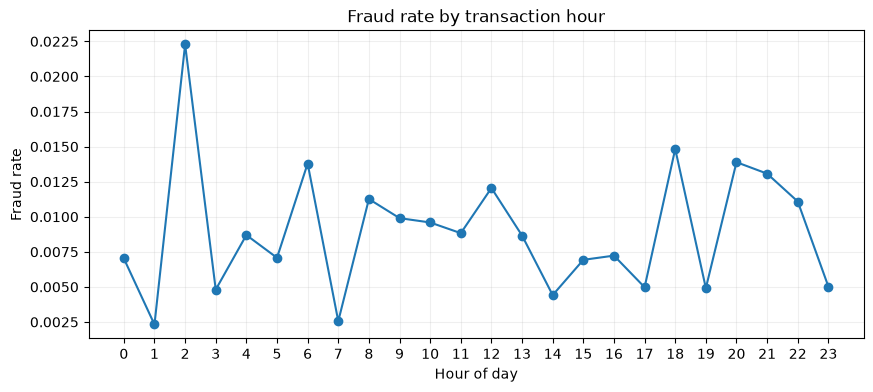

In [9]:
hourly_fraud_rate = df.groupby("transaction_hour")["is_fraud"].mean()

plt.figure(figsize=(10, 4))
hourly_fraud_rate.plot(marker="o")
plt.title("Fraud rate by transaction hour")
plt.xlabel("Hour of day")
plt.ylabel("Fraud rate")
plt.xticks(range(24))
plt.grid(alpha=0.2)
plt.show()


## 5. Chronological train / validation / test split

Randomly shuffling transaction records can make a fraud model look better than it would in the future because the test set can contain transactions from the same time period as the training data.

For this demo we use:

- **60% training** — learn the model
- **20% validation** — choose the model/threshold
- **20% test** — final untouched evaluation

The rows remain in chronological order.

In [10]:
n = len(df)
train_end = int(n * 0.60)
validation_end = int(n * 0.80)

train_df = df.iloc[:train_end].copy()
validation_df = df.iloc[train_end:validation_end].copy()
test_df = df.iloc[validation_end:].copy()

print(f"Train:      {len(train_df):,} rows | {train_df['transaction_date'].min()} → {train_df['transaction_date'].max()}")
print(f"Validation: {len(validation_df):,} rows | {validation_df['transaction_date'].min()} → {validation_df['transaction_date'].max()}")
print(f"Test:       {len(test_df):,} rows | {test_df['transaction_date'].min()} → {test_df['transaction_date'].max()}")


Train:      6,183 rows | 2022-01-01 00:35:32 → 2022-07-12 10:25:01
Validation: 2,061 rows | 2022-07-12 12:39:27 → 2022-09-15 22:53:54
Test:       2,061 rows | 2022-09-15 23:56:06 → 2022-11-21 19:49:23


## 5.5. A useful sanity check: how much signal is actually available?

Before celebrating a high accuracy score, compare the model's **PR-AUC** with the fraud prevalence. A classifier with no useful ranking signal has a PR-AUC close to the positive-class prevalence.

This dataset contains relatively few fraud cases, and many fraudulent transactions involve previously unseen sender/receiver IDs. That means the available data may simply not contain enough repeat behavioural signal for a strong production-style detector. A good ML pipeline should make that limitation visible rather than hide it behind accuracy.

In [11]:
fraud_prevalence = y_train.mean() if "y_train" in globals() else train_df["is_fraud"].mean()
print(f"Training fraud prevalence: {fraud_prevalence:.4%}")
print("A PR-AUC close to this value indicates weak ranking signal.")

print("\nFraudulent sender reuse in the training period:")
fraud_sender_counts = train_df.loc[train_df["is_fraud"] == 1, "sender_card_number"].value_counts()
print(f"Fraud cases: {len(fraud_sender_counts):,}")
print(f"Fraud senders with more than one fraud case: {(fraud_sender_counts > 1).sum():,}")


Training fraud prevalence: 1.0027%
A PR-AUC close to this value indicates weak ranking signal.

Fraudulent sender reuse in the training period:
Fraud cases: 62
Fraud senders with more than one fraud case: 0


## 6. Leakage-safe behavioural feature engineering

Card numbers are identifiers, not measurements. We therefore do **not** give the raw sender/receiver IDs to the model.

Instead, we derive features that describe transaction behaviour:

- number of previous transactions from the sender
- number of previous transactions to the receiver
- previous average amount for the sender
- previous average amount received by the receiver
- number of previously seen counterparties
- current amount relative to previous sender/receiver averages

The feature builder processes transactions in chronological order. A transaction can only use information that was available **before that transaction**. This is deliberately more conservative than calculating aggregates over the entire dataset.

In [12]:
def new_history_state():
    return {
        "sender_count": {},
        "receiver_count": {},
        "sender_amount_sum": {},
        "receiver_amount_sum": {},
        "sender_receivers": {},
        "receiver_senders": {},
    }


def copy_history_state(state):
    return {
        "sender_count": dict(state["sender_count"]),
        "receiver_count": dict(state["receiver_count"]),
        "sender_amount_sum": dict(state["sender_amount_sum"]),
        "receiver_amount_sum": dict(state["receiver_amount_sum"]),
        "sender_receivers": {k: set(v) for k, v in state["sender_receivers"].items()},
        "receiver_senders": {k: set(v) for k, v in state["receiver_senders"].items()},
    }


def transform_with_history(transactions, history_state=None, update_history=True):
    """Create behavioural features using only information available before each row."""
    state = history_state if history_state is not None else new_history_state()
    feature_rows = []

    for row in transactions.sort_values("transaction_date").itertuples(index=False):
        sender = row.sender_card_number
        receiver = row.receiver_cc_number
        amount = float(row.transaction_amount)

        sender_count = state["sender_count"].get(sender, 0)
        receiver_count = state["receiver_count"].get(receiver, 0)

        sender_average = (
            state["sender_amount_sum"].get(sender, 0.0) / sender_count
            if sender_count else 0.0
        )
        receiver_average = (
            state["receiver_amount_sum"].get(receiver, 0.0) / receiver_count
            if receiver_count else 0.0
        )

        sender_receivers = state["sender_receivers"].get(sender, set())
        receiver_senders = state["receiver_senders"].get(receiver, set())

        feature_rows.append({
            "transaction_amount": amount,
            "transaction_hour": row.transaction_hour,
            "transaction_day_of_week": row.transaction_day_of_week,
            "is_weekend": row.is_weekend,
            "sender_transaction_count": sender_count,
            "receiver_transaction_count": receiver_count,
            "sender_average_amount": sender_average,
            "receiver_average_amount": receiver_average,
            "sender_unique_receivers": len(sender_receivers),
            "receiver_unique_senders": len(receiver_senders),
            "amount_vs_sender_average": amount / sender_average if sender_average > 0 else 0.0,
            "amount_vs_receiver_average": amount / receiver_average if receiver_average > 0 else 0.0,
        })

        if update_history:
            state["sender_count"][sender] = sender_count + 1
            state["receiver_count"][receiver] = receiver_count + 1
            state["sender_amount_sum"][sender] = state["sender_amount_sum"].get(sender, 0.0) + amount
            state["receiver_amount_sum"][receiver] = state["receiver_amount_sum"].get(receiver, 0.0) + amount
            state["sender_receivers"].setdefault(sender, set()).add(receiver)
            state["receiver_senders"].setdefault(receiver, set()).add(sender)

    return pd.DataFrame(feature_rows), state


### Build features for each split

Training transactions build the initial history. Validation transactions can use training history plus earlier validation transactions. Test transactions can use training + validation history, but **never test labels or future test transactions**.

In [13]:
train_features, history_after_train = transform_with_history(train_df, update_history=True)

validation_state = copy_history_state(history_after_train)
validation_features, history_after_validation = transform_with_history(
    validation_df,
    history_state=validation_state,
    update_history=True,
)

test_state = copy_history_state(history_after_validation)
test_features, _ = transform_with_history(
    test_df,
    history_state=test_state,
    update_history=False,
)

y_train = train_df["is_fraud"].to_numpy()
y_validation = validation_df["is_fraud"].to_numpy()
y_test = test_df["is_fraud"].to_numpy()

feature_columns = train_features.columns.tolist()

print("Features used by the model:")
for column in feature_columns:
    print(f"- {column}")


Features used by the model:
- transaction_amount
- transaction_hour
- transaction_day_of_week
- is_weekend
- sender_transaction_count
- receiver_transaction_count
- sender_average_amount
- receiver_average_amount
- sender_unique_receivers
- receiver_unique_senders
- amount_vs_sender_average
- amount_vs_receiver_average


## 7. Establish a simple baseline

We start with a Random Forest using class weights. This gives us a baseline without synthetic oversampling. Accuracy is intentionally not treated as the main metric.

In [14]:
def evaluate_predictions(y_true, probabilities, threshold=0.5, title="Model"):
    predictions = (probabilities >= threshold).astype(int)

    precision = precision_score(y_true, predictions, zero_division=0)
    recall = recall_score(y_true, predictions, zero_division=0)
    f1 = f1_score(y_true, predictions, zero_division=0)
    pr_auc = average_precision_score(y_true, probabilities)
    roc_auc = roc_auc_score(y_true, probabilities)

    print(title)
    print(f"Threshold: {threshold:.3f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, predictions, target_names=["Legitimate", "Fraud"], zero_division=0))

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
    }

baseline_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

baseline_model.fit(train_features, y_train)
validation_probabilities = baseline_model.predict_proba(validation_features)[:, 1]

baseline_metrics = evaluate_predictions(
    y_validation,
    validation_probabilities,
    threshold=0.5,
    title="Class-weighted Random Forest — validation set",
)


Class-weighted Random Forest — validation set
Threshold: 0.500
Precision: 0.0000
Recall:    0.0000
F1:        0.0000
PR-AUC:    0.0118
ROC-AUC:   0.5040

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      2044
       Fraud       0.00      0.00      0.00        17

    accuracy                           0.98      2061
   macro avg       0.50      0.50      0.50      2061
weighted avg       0.98      0.98      0.98      2061



## 8. Compare with SMOTE — without leaking the validation set

SMOTE is fitted **only on the training data**. The validation and test sets are never oversampled.

In [15]:
smote_model = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

smote_model.fit(train_features, y_train)
smote_validation_probabilities = smote_model.predict_proba(validation_features)[:, 1]

smote_metrics = evaluate_predictions(
    y_validation,
    smote_validation_probabilities,
    threshold=0.5,
    title="Random Forest + SMOTE — validation set",
)


Random Forest + SMOTE — validation set
Threshold: 0.500
Precision: 0.0045
Recall:    0.0588
F1:        0.0084
PR-AUC:    0.0079
ROC-AUC:   0.4647

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.89      0.94      2044
       Fraud       0.00      0.06      0.01        17

    accuracy                           0.89      2061
   macro avg       0.50      0.48      0.47      2061
weighted avg       0.98      0.89      0.93      2061



In [16]:
comparison = pd.DataFrame(
    [baseline_metrics, smote_metrics],
    index=["Class weights", "SMOTE"],
)
comparison[["precision", "recall", "f1", "pr_auc", "roc_auc"]]


,precision,recall,f1,pr_auc,roc_auc
Class weights,0.000000,0.000000,0.000000,0.011839,0.504015
SMOTE,0.004545,0.058824,0.008439,0.007922,0.464660


## 9. Select a fraud decision threshold

A probability of 0.5 is not automatically the correct fraud threshold. In a real system, the threshold depends on the cost of false positives and false negatives.

For this demonstration we select the threshold that gives the best **F1 score on the validation set**. This is a teaching choice, not a claim that F1 is the correct business objective for a bank.

In [17]:
# Use the validation model with the better validation PR-AUC as the candidate model.
if smote_metrics["pr_auc"] > baseline_metrics["pr_auc"]:
    candidate_model = smote_model
    candidate_validation_probabilities = smote_validation_probabilities
    candidate_name = "Random Forest + SMOTE"
else:
    candidate_model = baseline_model
    candidate_validation_probabilities = validation_probabilities
    candidate_name = "Class-weighted Random Forest"

thresholds = np.linspace(0.05, 0.95, 91)
threshold_results = []

for threshold in thresholds:
    predictions = (candidate_validation_probabilities >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_validation, predictions, zero_division=0),
        "recall": recall_score(y_validation, predictions, zero_division=0),
        "f1": f1_score(y_validation, predictions, zero_division=0),
    })

threshold_table = pd.DataFrame(threshold_results)
best_threshold = float(threshold_table.loc[threshold_table["f1"].idxmax(), "threshold"])

print(f"Candidate model: {candidate_name}")
print(f"Selected validation threshold: {best_threshold:.3f}")


Candidate model: Class-weighted Random Forest
Selected validation threshold: 0.460


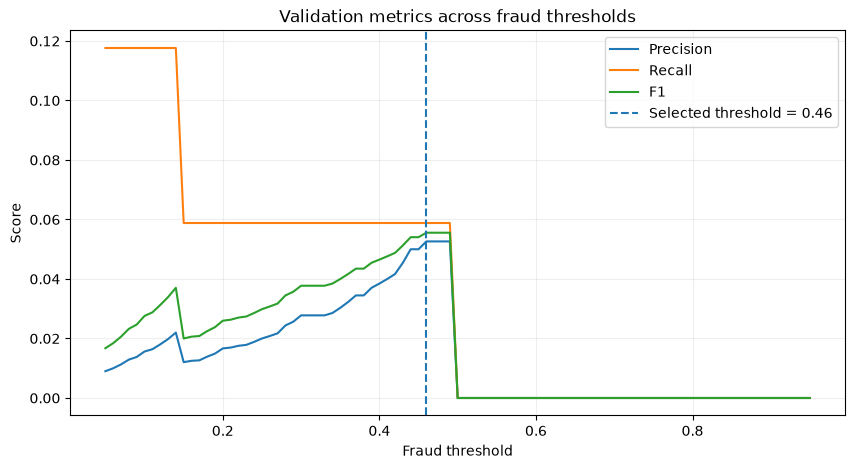

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
plt.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
plt.plot(threshold_table["threshold"], threshold_table["f1"], label="F1")
plt.axvline(best_threshold, linestyle="--", label=f"Selected threshold = {best_threshold:.2f}")
plt.xlabel("Fraud threshold")
plt.ylabel("Score")
plt.title("Validation metrics across fraud thresholds")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 10. Train the final model on training + validation history

The validation set has now served its purpose: model comparison and threshold selection. We can use training + validation transactions to fit the final model, while keeping the test period untouched for the final evaluation.

The feature state for the final model is therefore also built only from transactions that occurred before the test period.

In [19]:
development_df = pd.concat([train_df, validation_df], ignore_index=True)

development_features, development_history = transform_with_history(
    development_df,
    update_history=True,
)
y_development = development_df["is_fraud"].to_numpy()

final_state_for_test = copy_history_state(development_history)
final_test_features, _ = transform_with_history(
    test_df,
    history_state=final_state_for_test,
    update_history=False,
)

if candidate_name == "Random Forest + SMOTE":
    final_model = ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])
else:
    final_model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

final_model.fit(development_features, y_development)
test_probabilities = final_model.predict_proba(final_test_features)[:, 1]

final_test_metrics = evaluate_predictions(
    y_test,
    test_probabilities,
    threshold=best_threshold,
    title=f"Final model — untouched test period ({candidate_name})",
)


Final model — untouched test period (Class-weighted Random Forest)
Threshold: 0.460
Precision: 0.0000
Recall:    0.0000
F1:        0.0000
PR-AUC:    0.0092
ROC-AUC:   0.5715

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      2047
       Fraud       0.00      0.00      0.00        14

    accuracy                           0.98      2061
   macro avg       0.50      0.50      0.50      2061
weighted avg       0.99      0.98      0.99      2061



## 11. Final confusion matrix

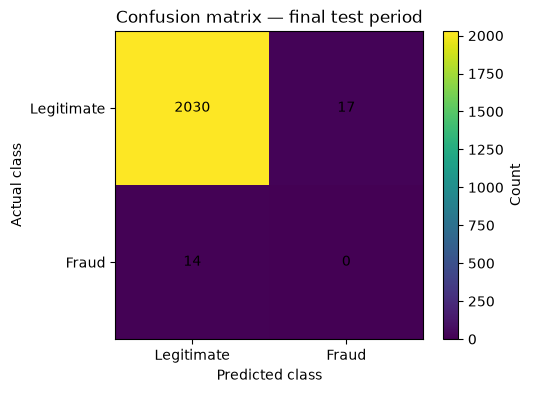

In [20]:
test_predictions = (test_probabilities >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion matrix — final test period")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.yticks([0, 1], ["Legitimate", "Fraud"])

for row in range(2):
    for column in range(2):
        plt.text(column, row, cm[row, column], ha="center", va="center")

plt.colorbar(label="Count")
plt.show()


## 12. Feature importance

Feature importance is useful for a demo, but it should not be interpreted as proof that a feature causes fraud. It simply indicates how much the fitted tree ensemble used each feature.

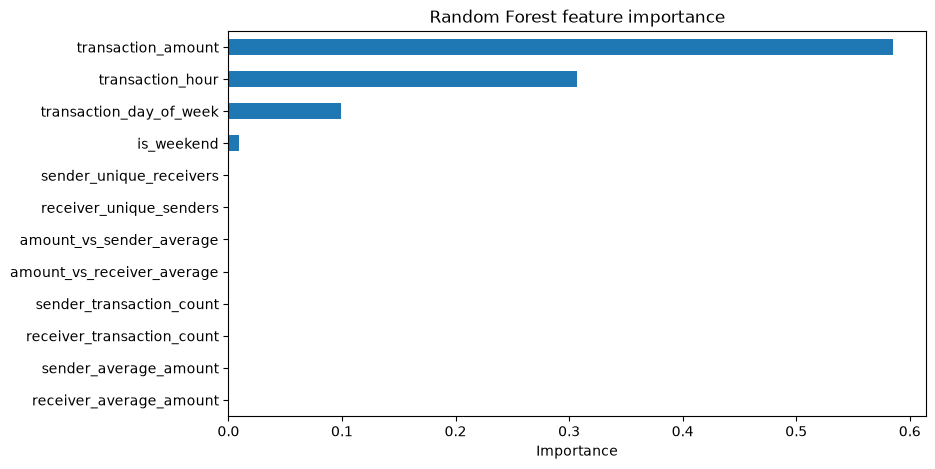

transaction_amount            0.584941
transaction_hour              0.306567
transaction_day_of_week       0.099178
is_weekend                    0.009314
sender_transaction_count      0.000000
receiver_transaction_count    0.000000
sender_average_amount         0.000000
receiver_average_amount       0.000000
sender_unique_receivers       0.000000
receiver_unique_senders       0.000000
amount_vs_sender_average      0.000000
amount_vs_receiver_average    0.000000
dtype: float64

In [21]:
classifier = final_model.named_steps["classifier"] if hasattr(final_model, "named_steps") else final_model

importance = pd.Series(
    classifier.feature_importances_,
    index=feature_columns,
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importance.sort_values().plot(kind="barh")
plt.title("Random Forest feature importance")
plt.xlabel("Importance")
plt.show()

importance


## 13. Save the complete inference bundle

A production system should not save only the classifier. Inference also needs the feature-building state and the selected decision threshold.

The bundle below contains:

- the trained model
- the feature column order
- the historical transaction state used for future feature generation
- the selected fraud threshold
- metadata describing the model

For a real service, the state would normally be replaced by a proper feature store or online transaction-history service.

In [23]:
model_bundle = {
    "model": final_model,
    "feature_columns": feature_columns,
    "history_state": development_history,
    "fraud_threshold": best_threshold,
    "model_name": candidate_name,
    "random_state": RANDOM_STATE,
}

model_path = MODEL_DIR / "fraud_detection_pipeline.joblib"
joblib.dump(model_bundle, model_path)

print(f"Saved model bundle to: {model_path.resolve()}")


Saved model bundle to: /home/peter/PycharmProjects/bank_system/dataset and notebook/models/fraud_detection_pipeline.joblib


## 14. Production-style inference example

The function below accepts a new transaction and derives the same features used during training. It returns both a probability and a decision.

In a real application, the historical state would be updated by the transaction-processing system after the transaction is accepted/processed rather than stored permanently inside a notebook artefact.

In [24]:
def build_single_transaction_features(sender_card_number, receiver_cc_number, amount, transaction_date, history_state):
    transaction_date = pd.Timestamp(transaction_date)
    sender_count = history_state["sender_count"].get(sender_card_number, 0)
    receiver_count = history_state["receiver_count"].get(receiver_cc_number, 0)

    sender_average = (
        history_state["sender_amount_sum"].get(sender_card_number, 0.0) / sender_count
        if sender_count else 0.0
    )
    receiver_average = (
        history_state["receiver_amount_sum"].get(receiver_cc_number, 0.0) / receiver_count
        if receiver_count else 0.0
    )

    return pd.DataFrame([{
        "transaction_amount": float(amount),
        "transaction_hour": transaction_date.hour,
        "transaction_day_of_week": transaction_date.dayofweek,
        "is_weekend": int(transaction_date.dayofweek >= 5),
        "sender_transaction_count": sender_count,
        "receiver_transaction_count": receiver_count,
        "sender_average_amount": sender_average,
        "receiver_average_amount": receiver_average,
        "sender_unique_receivers": len(history_state["sender_receivers"].get(sender_card_number, set())),
        "receiver_unique_senders": len(history_state["receiver_senders"].get(receiver_cc_number, set())),
        "amount_vs_sender_average": float(amount) / sender_average if sender_average > 0 else 0.0,
        "amount_vs_receiver_average": float(amount) / receiver_average if receiver_average > 0 else 0.0,
    }], columns=feature_columns)


def predict_transaction(sender_card_number, receiver_cc_number, amount, transaction_date, bundle):
    features = build_single_transaction_features(
        sender_card_number=sender_card_number,
        receiver_cc_number=receiver_cc_number,
        amount=amount,
        transaction_date=transaction_date,
        history_state=bundle["history_state"],
    )

    probability = float(bundle["model"].predict_proba(features)[0, 1])
    decision = "FRAUD_REVIEW" if probability >= bundle["fraud_threshold"] else "APPROVE"

    return {
        "fraud_probability": probability,
        "threshold": bundle["fraud_threshold"],
        "decision": decision,
    }

loaded_bundle = joblib.load(model_path)

example_result = predict_transaction(
    sender_card_number=train_df.iloc[-1]["sender_card_number"],
    receiver_cc_number=train_df.iloc[-1]["receiver_cc_number"],
    amount=float(train_df.iloc[-1]["transaction_amount"]),
    transaction_date=test_df.iloc[0]["transaction_date"],
    bundle=loaded_bundle,
)

example_result


{'fraud_probability': 0.0,
 'threshold': 0.4599999999999999,
 'decision': 'APPROVE'}

## 15. What this demo still does not solve

This is deliberately a practical demonstration rather than a claim of production readiness.

A real fraud platform would normally add:

1. **Real-time velocity features** — transactions in the last 1/5/15/60 minutes.
2. **Customer and account history** — account age, previous fraud, normal spending behaviour.
3. **Device and network signals** — device fingerprint, IP, ASN, location, proxy/VPN signals.
4. **Feature store / online state** — low-latency access to recent transaction history.
5. **Probability calibration** — if the score is going to be interpreted as a probability.
6. **Model monitoring** — drift, fraud rate, precision/recall, latency, feature quality.
7. **Champion/challenger evaluation** — compare new models against the deployed model.
8. **Human review workflow** — medium-risk transactions can be sent for investigation rather than automatically blocked.
9. **Feedback loop** — confirmed fraud and confirmed legitimate cases become labelled training data.
10. **Retraining strategy** — scheduled or triggered by data/model drift.

The important improvement is that the notebook now separates **model training**, **evaluation**, **decision threshold**, and **inference state**, which are often incorrectly mixed together in small ML demos.